# Transfer Learning with MobileNetV2

## الترتيب / Flow
1. استيراد المكتبات - Import libraries
2. قراءة البيانات - Load MNIST sample CSV
3. تجهيز الصور - Resize to 224x224 RGB + normalize
4. تقسيم البيانات - Train/Test split
5. بناء MobileNetV2 - Pretrained base + new head
6. تجميد Base - Freeze pretrained layers
7. تدريب الرأس - Train classifier head
8. التقييم - Test accuracy
9. عرض تنبؤات - Sample predictions

In [1]:
# Step 1) استيراد المكتبات / Import libraries
# pip install tensorflow -q  # uncomment in Colab if needed
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Input

In [2]:
# Step 2) قراءة البيانات / Load dataset
dataset = pd.read_csv('mnist_sample.csv')
print('Shape:', dataset.shape)
dataset.head()

Shape: (500, 785)


,label,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,...,pixel_774,pixel_775,pixel_776,pixel_777,pixel_778,pixel_779,pixel_780,pixel_781,pixel_782,pixel_783
0,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
# Step 3) تجهيز الصور / Prepare images for MobileNetV2 (224x224 RGB)
y = dataset['label'].values.astype(int)
pixel_cols = [c for c in dataset.columns if c.startswith('pixel_')]
X_gray = dataset[pixel_cols].values.reshape(-1, 28, 28, 1).astype('float32')

# Grayscale -> RGB and resize to 224x224
X_rgb = np.repeat(X_gray, 3, axis=-1)
X_resized = tf.image.resize(X_rgb, (224, 224)).numpy()
X_resized = preprocess_input(X_resized)
print('Prepared shape:', X_resized.shape)

Prepared shape: (500, 224, 224, 3)


In [4]:
# Step 4) تقسيم البيانات / Train-Test split
X_train, X_test, y_train, y_test = train_test_split(
    X_resized, y, test_size=0.2, random_state=0, stratify=y
)

In [5]:
# Step 5) بناء MobileNetV2 / Build transfer learning model
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

inputs = Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
outputs = Dense(10, activation='softmax')(x)
model = Model(inputs, outputs)
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 2,236,682 (8.53 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [6]:
# Step 6) تجميد Base / Freeze pretrained layers
base_model.trainable = False
print(f'Trainable layers: {sum([l.trainable for l in model.layers])}')

Trainable layers: 3


In [7]:
# Step 7) تدريب الرأس / Train classifier head only
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=16,
    verbose=1
)

Epoch 1/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 218ms/step - accuracy: 0.3313 - loss: 2.0140 - val_accuracy: 0.4125 - val_loss: 1.7415
Epoch 2/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 174ms/step - accuracy: 0.7094 - loss: 1.2079 - val_accuracy: 0.7125 - val_loss: 1.1548
Epoch 3/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 178ms/step - accuracy: 0.8219 - loss: 0.8105 - val_accuracy: 0.7875 - val_loss: 0.9095
Epoch 4/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 173ms/step - accuracy: 0.8906 - loss: 0.6117 - val_accuracy: 0.8000 - val_loss: 0.7670
Epoch 5/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 180ms/step - accuracy: 0.9156 - loss: 0.4931 - val_accuracy: 0.8500 - val_loss: 0.6833


In [8]:
# Step 8) التقييم / Evaluate
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f'Test loss: {loss:.4f}')
print(f'Test accuracy: {accuracy:.2%}')

Test loss: 0.6870
Test accuracy: 87.00%


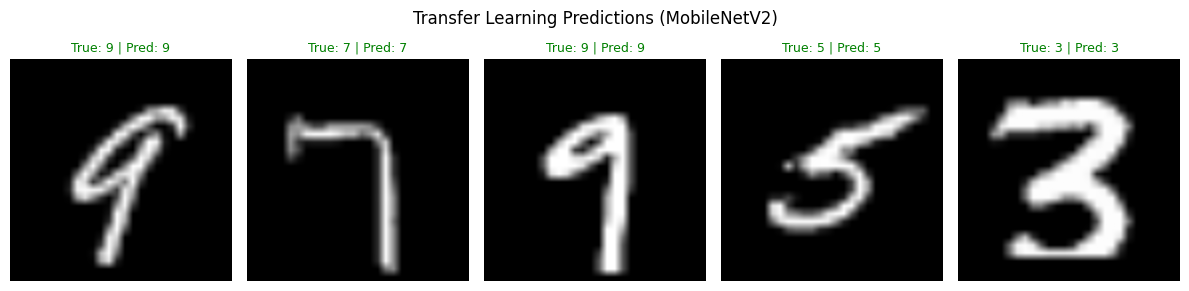

In [9]:
# Step 9) عرض تنبؤات / Visualize predictions
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i, ax in enumerate(axes):
    ax.imshow(X_test[i].astype('float32') * 0.5 + 0.5)  # rough de-normalize for display
    color = 'green' if y_pred[i] == y_test[i] else 'red'
    ax.set_title(f'True: {y_test[i]} | Pred: {y_pred[i]}', color=color, fontsize=9)
    ax.axis('off')
plt.suptitle('Transfer Learning Predictions (MobileNetV2)')
plt.tight_layout()
plt.show()